Imports

In [188]:
import os
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import xlsxwriter
from xlsxwriter.utility import xl_rowcol_to_cell

# change the font to LM Roman 12
import matplotlib.font_manager as fm
fm.fontManager.addfont('C://Users//hoel_m0//AppData//Local//Microsoft//Windows//Fonts//latin-modern-roman.mroman12-regular.otf')
plt.rcParams['font.family'] = 'Latin Modern Roman'
# make the font size larger
plt.rcParams.update({'font.size': 13})

from utils import *

Read deterministic results

In [ ]:
# Set functional units (more descriptive names can be added)
fu_list = ['FC', 'FH', 'ASK', 'Month', 'Year', 'Life']

# Header names
# headers = ['Parameter', 'ADP', 'CC', 'FETP', 'FEP', 'MEP', 'TEP', 'HHC', 'HHNC', 'IR', 'LU', 'MM', 'ODP', 'PM', 'POxF', 'WS']
headers = ['Parameter', 'ADP', 'FETP', 'TEP', 'HHC', 'HHNC', 'ODP', 'CC', 'ECF', 'FEP', 'MEP', 'IR', 'LU', 'MM', 'PM', 'POxF', 'WS']
impact_categories = headers[1:]

# Columns to read from the excel files
columns = 'B,F,G,K,L,P,T,U,Y,Z,AA,AB,AC,AD,AE,AF,AG'

overview_data = pd.read_excel(r"G:\Studenten\PLM\MariaHoeller\Overview_Individual_LCAs.xlsx")

# Read deterministic scores from reference case
output_folder_path = r"C:\Git_LYFE\airlyfe\projects\thesis_lsa\outputs"
referencecase_path = os.path.join(output_folder_path, "D250-TF_eco.xlsx")


# read the deterministic results into a dataframe
deterministic_inputs = pd.read_excel(referencecase_path, sheet_name="Individual LCAs", usecols=columns, skiprows=3, nrows=23)
deterministic_outputs = pd.read_excel(referencecase_path, sheet_name="Summary", usecols="D:I", skiprows=30, nrows=16)

# print(deterministic_outputs)

Store deterministic results and 'clean' names in a dictionary

In [ ]:
# create a list of dictionaries to store the results
parameters = [{'name': list(deterministic_inputs['Name'])[i]} for i in range (len(list(deterministic_inputs['Name'])))]

# loop through the parameters and store the results in the dictionaries
for param_idx, parameter in enumerate(parameters):
    
    # create a dictionary to store the nominal values of the inputs and outputs
    parameter['x_nominal'] = {}
    parameter['y_nominal'] = {}
    
    # find the correct data via iloc from the deterministic inputs
    for impcat_idx, impact_category in enumerate(impact_categories):
        
        # store the nominal values of the inputs
        parameter['x_nominal'][impact_category] = deterministic_inputs.iloc[param_idx][impcat_idx+1]
        
        # store the nominal values of the outputs
        parameter['y_nominal'][impact_category] = {}
        for fu_idx, fu in enumerate(fu_list):
            parameter['y_nominal'][impact_category][fu] = deterministic_outputs.iloc[impcat_idx][fu_idx]

    parameter['name_plots'] = overview_data.loc[overview_data['Demand name'].str.lower() == parameter['name'].lower(), 'Name for Plots'].values[0]
    
    print(parameter['name_plots'],"\n Nominal inputs: ",parameter['x_nominal'])


Read LSA results

In [ ]:
# DataFrames to store inputs and outputs
sensitivity_df = pd.DataFrame()
elasticity_df = pd.DataFrame()
i = 0

inputs_list = []
outputs_list = []
filename_list = []

# Process all "_eco.xlsx" files
for file in os.listdir(output_folder_path):
    if file.endswith("_eco.xlsx") and not file.endswith("_vs_referencecase_eco.xlsx") and not file.startswith("D250-TF"):
        i += 1
        
        # read the data from the file
        file_path = os.path.join(output_folder_path, file)
        inputs_list.append(pd.read_excel(file_path, sheet_name="Individual LCAs", usecols=columns, skiprows=3, nrows=23))
        outputs_list.append(pd.read_excel(file_path, sheet_name="Summary", usecols="D:I", skiprows=30, nrows=16))
        filename_list.append(file)
        
print(f"Successfully read the data from {i} files in the folder {output_folder_path}")


Store LSA results in the dictionary and calculate sensitivity/elasticity

Sensitivity = $\frac{\Delta y}{\Delta x}$

Elasticity = $\frac{x_\text{nominal} \Delta y}{y_\text{nominal} \Delta x}$

In [156]:
for file_idx, (input, filename) in enumerate(zip(inputs_list, filename_list)):
        
        # loop through the parameters and store the results in the dictionaries
        for param_idx, parameter in enumerate(parameters):
            
            # create a dictionary to store the changed values of the inputs
            changed_inputs = {}
            
            # find the changed input values
            for impcat_idx, impact_category in enumerate(impact_categories):
                changed_inputs[impact_category] = input.iloc[param_idx][impcat_idx+1]
                
            # compare the changed inputs to the nominal inputs and find the changed ones        
            if changed_inputs != parameter['x_nominal']:
                parameter['file_idx'] = file_idx
                parameter['x_changed'] = changed_inputs
                parameter['file'] = filename
           
# loop over the parameters and find the correct outputs
for parameter in parameters:
    
    parameter['y_changed'] = {}
    parameter['sensitivity'] = {}
    parameter['elasticity'] = {}
    
    print(parameter['name'])
    for impcat_idx, impact_category in enumerate(impact_categories):
        parameter['sensitivity'][impact_category] = {}
        parameter['elasticity'][impact_category] = {}
        
        # store the changed values of the outputs
        parameter['y_changed'][impact_category] = {}
        for fu_idx, fu in enumerate(fu_list):
            parameter['y_changed'][impact_category][fu] = outputs_list[parameter['file_idx']].iloc[impcat_idx][fu_idx]
        
        # calculate the sensitivity and elasticity
        for fu in fu_list:            
            delta_x = parameter['x_changed'][impact_category] - parameter['x_nominal'][impact_category]
            delta_y = parameter['y_changed'][impact_category][fu] - parameter['y_nominal'][impact_category][fu]
            
            sensitivity = delta_y / delta_x
            elasticity = parameter['x_nominal'][impact_category] * delta_y / parameter['y_nominal'][impact_category][fu] * delta_x
            
            parameter['sensitivity'][impact_category][fu] = sensitivity
            parameter['elasticity'][impact_category][fu] = elasticity
       


Aircraft
market for transport, freight, aircraft, medium haul
market for transport, passenger aircraft, very short haul
market for transport, passenger aircraft, short haul
market for transport, passenger aircraft, medium haul
market for transport, passenger aircraft, long haul
Kerosene
A-Check
APU Shop Visit
C-Check
D-Check
Daily Check
Full Overhaul
Hot Section Inspection
LLP Compressor
LLP Fan
LLP HPT
LLP LPT
Landing Gear Shop Visit
Pre Flight
Transit
Weekly Check
market for electricity, medium voltage


KeyError: 'file_idx'

Function to make the report look nice

In [185]:
# funtion to make the report look nice in the LYFE format
def initialize_report(workbook, writer):
    # In line with the DLR template, the font is set
    workbook.formats[0].set_font_name('Frutiger 45 Light')

    formats_dict = {
        'title': {
            'font_size': 18,
            'bold': True,
            'font_color': '#7b7b84',
            'align': 'center',
            'valign': 'vcenter',
            'bg_color': 'white',
            'bottom': 2,
        },
        'white': {
            'bg_color': 'white',
        },
        'white+blackbottom': {
            'bg_color': 'white',
            'bottom': 2,
        }
    }

    formats = {key: workbook.add_format(val) for key, val in formats_dict.items()}

    worksheets = ['FC', 'FH', 'ASK', 'Month', 'Year', 'Life']
    worksheet_titles = ['LSA Results per Flight Cycle', 'LSA Results per Flight Hour', 
                        'LSA Results per Available Seat Kilometer', 'LSA Results per Month', 
                        'LSA Results per Year', 'LSA Results per Life']
    
    worksheets = ['Sensitivity', 'Elasticity']
    worksheet_titles = worksheets

    for i, worksheet in enumerate(worksheets):
        ws = workbook.add_worksheet(worksheet)
        ws.set_row(0, 47.25, formats['white+blackbottom'])
        ws.set_row(1, 15, formats['white'])
        ws.set_column(0, 0, 2)
        ws.set_column(1, 2, 16)
        ws.set_column(3, 10000, 13)

        ws.merge_range('J1:G1', worksheet_titles[i], formats['title'])

        dpath_logos = r"C:\Git_LYFE\airlyfe\airlyfe\otherstuff"
        ws.insert_image('A1', filename=os.path.join(dpath_logos, 'logos.png'), options={'x_scale': 0.88886})

        writer.sheets[worksheet] = ws

    return workbook, writer

def apply_conditional_formatting(worksheet, dataframe, startrow, startcol):
    # Calculate the number of rows and columns in the DataFrame
    number_of_rows = dataframe.shape[0]
    number_of_cols = dataframe.shape[1]

    # The data starts from the cell after the header (which is at startrow)
    data_start_row = startrow + 1  # +1 to skip the column headers
    data_start_col = startcol + 1  # +1 to skip the index column ('Parameter')

    # The data ends at:
    data_end_row = data_start_row + number_of_rows - 1
    data_end_col = data_start_col + number_of_cols - 1

    # Create the cell range string
    start_cell = xl_rowcol_to_cell(data_start_row, data_start_col)
    end_cell = xl_rowcol_to_cell(data_end_row, data_end_col)

    cell_range = f'{start_cell}:{end_cell}'

    # Define your conditional formatting rule
    conditional_format = {
        'type': '3_color_scale',  # You can change this to '2_color_scale' or 'data_bar' as needed
        # For more advanced rules, specify 'min_type', 'mid_type', 'max_type', etc.
        'min_type': 'percentile',
        'min_value': 15,
        'min_color': '#73a237',
        'mid_type': 'percentile',
        'mid_value': 50,
        'mid_color': '#e0b02e',
        'max_type': 'percentile',
        'max_value': 85,
        'max_color': '#a44a3f'
    }

    # Apply the conditional formatting
    worksheet.conditional_format(cell_range, conditional_format)

Write the report

In [189]:
# set the output filename
output_file = os.path.join(output_folder_path, "lsa_results.xlsx")

# create the excel writer
writer = pd.ExcelWriter(output_file, engine='xlsxwriter')
workbook = writer.book
workbook, writer = initialize_report(workbook, writer)

# create lists for the sensitivity and elasticity DataFrames
sensitivity_dataframes = []
elasticity_dataframes = []


# write the parameter results to the excel file
with writer as writer:
    # for fu in fu_list:
    #     sensitivity_df = pd.DataFrame()
    #     elasticity_df = pd.DataFrame()
    #     for parameter in parameters[:-1]: ## once everything is working, remove the [:-1]!!
    #         for impact_category in impact_categories:
    #             sensitivity_df.at[parameter['name'], impact_category] = parameter['sensitivity'][impact_category][fu]
    #             elasticity_df.at[parameter['name'], impact_category] = parameter['elasticity'][impact_category][fu]
    #     sensitivity_df.to_excel(writer, sheet_name=fu, startrow=4, startcol=3, index_label='Parameter')
    #     elasticity_df.to_excel(writer, sheet_name=fu, startrow=4, startcol=3+len(impact_categories)+2, index_label='Parameter')
    
    worksheet_sensitivity = writer.sheets['Sensitivity']
    worksheet_elasticity = writer.sheets['Elasticity']
    
    # loop through each FU, create the sensitivity and elasticity DataFrames and write them to the file
    for fu_idx, fu in enumerate(fu_list):
        sensitivity_df = pd.DataFrame()
        elasticity_df = pd.DataFrame()

        # loop through the parameters and store the results for each FU in the correct DataFrames
        for parameter in parameters:
            for impact_category in impact_categories:
                sensitivity_df.at[parameter['name_plots'], impact_category] = parameter['sensitivity'][impact_category][fu]
                elasticity_df.at[parameter['name_plots'], impact_category] = parameter['elasticity'][impact_category][fu]   
                           
        # write the sensitivity to the excel file
        worksheet_sensitivity.write(3+fu_idx*(3+len(parameters)), 1, fu)
        sensitivity_df.to_excel(writer, sheet_name='Sensitivity', startrow=4+fu_idx*(3+len(parameters)), startcol=1, index_label='Parameter')
        sensitivity_dataframes.append(sensitivity_df)
        
        # write the elasticity to the excel file
        worksheet_elasticity.write(3+fu_idx*(3+len(parameters)), 1, fu)
        elasticity_df.to_excel(writer, sheet_name='Elasticity', startrow=4+fu_idx*(3+len(parameters)), startcol=1, index_label='Parameter')
        elasticity_dataframes.append(elasticity_df)
        
        # apply conditional formatting
        apply_conditional_formatting(worksheet_sensitivity, sensitivity_df, startrow=4+fu_idx*(3+len(parameters)), startcol=1)
        apply_conditional_formatting(worksheet_elasticity, elasticity_df, startrow=4+fu_idx*(3+len(parameters)), startcol=1)
        

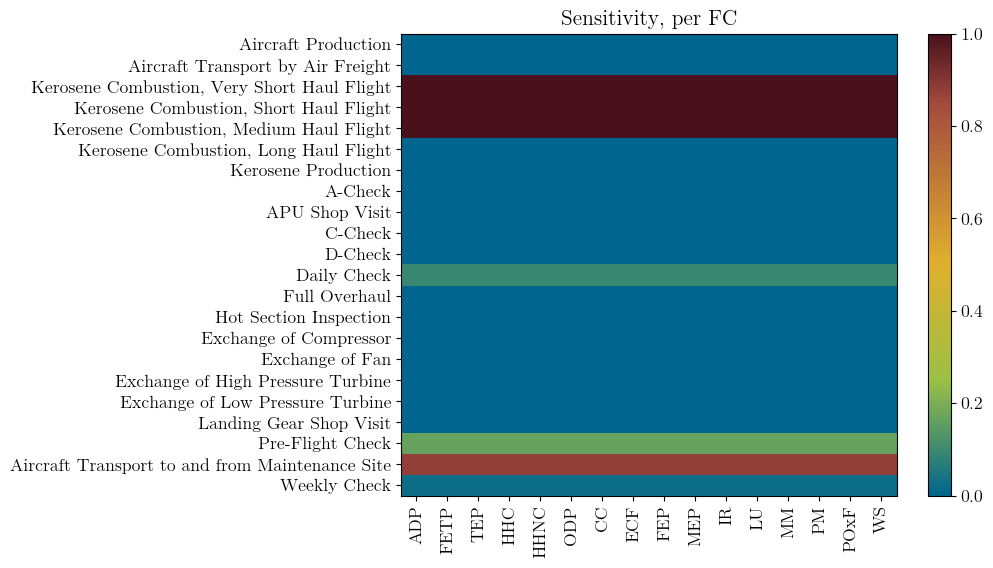

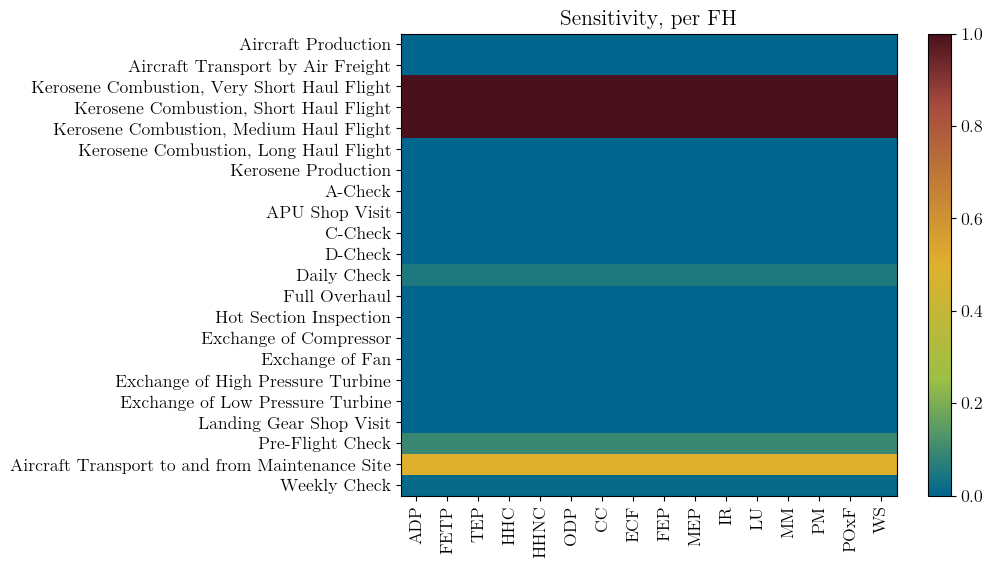

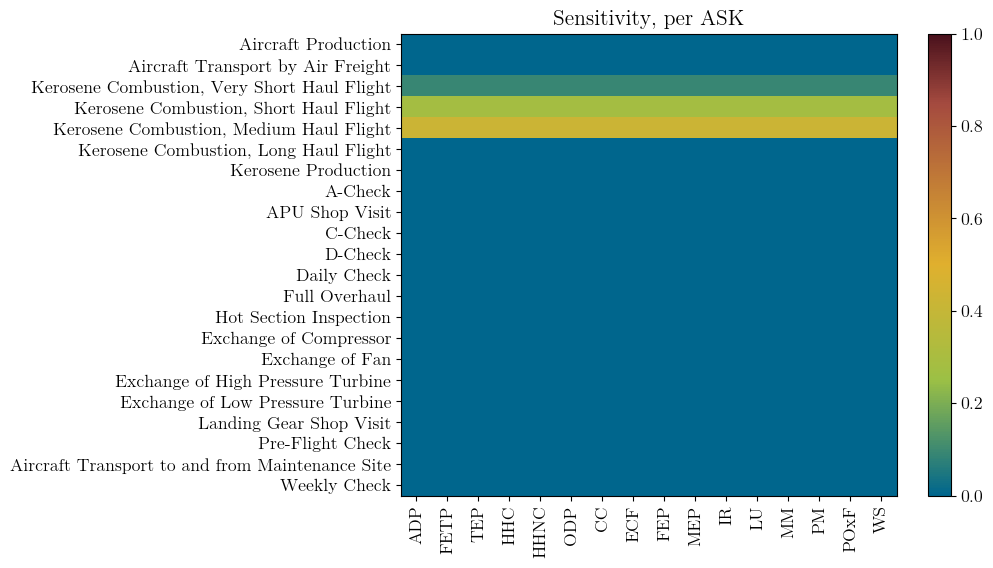

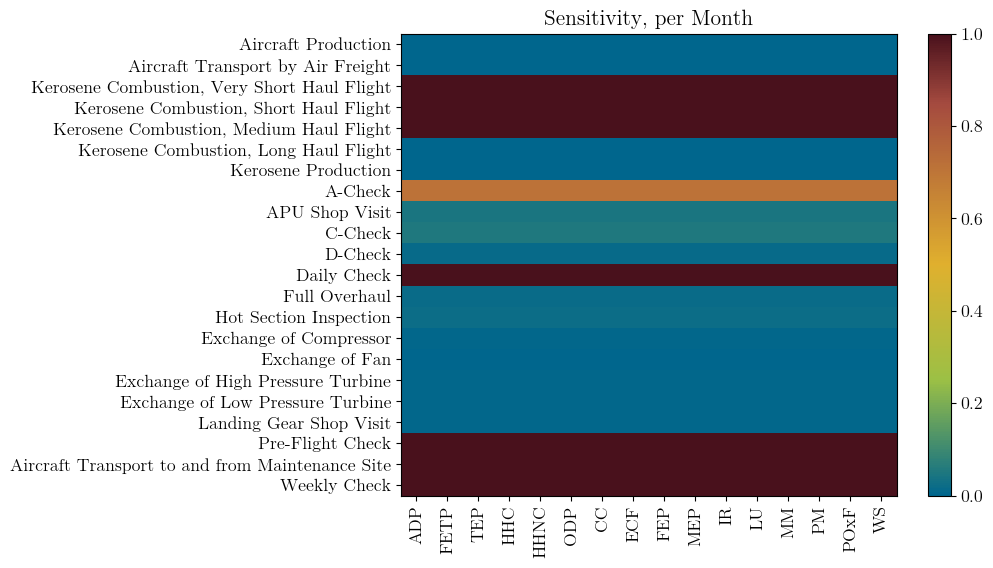

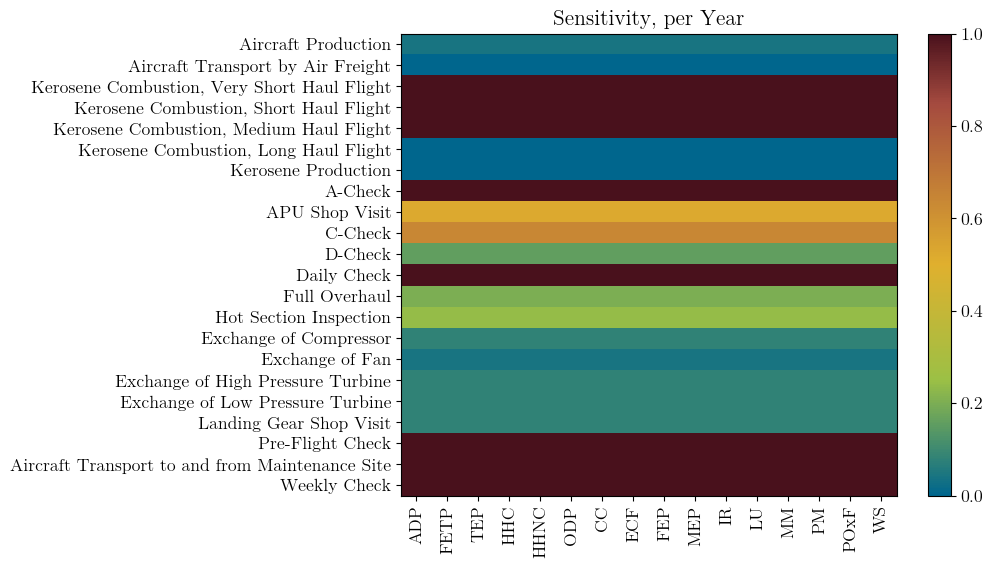

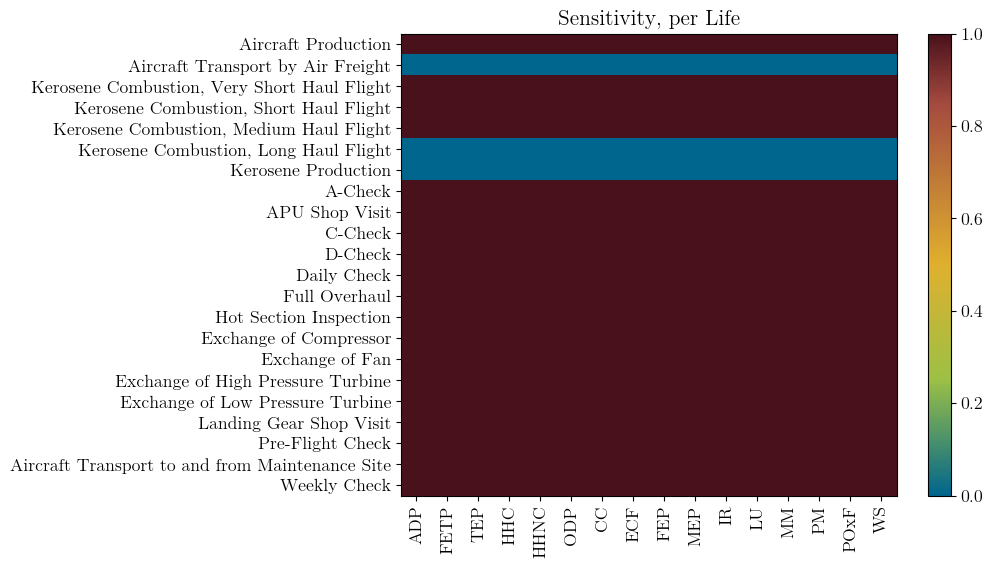

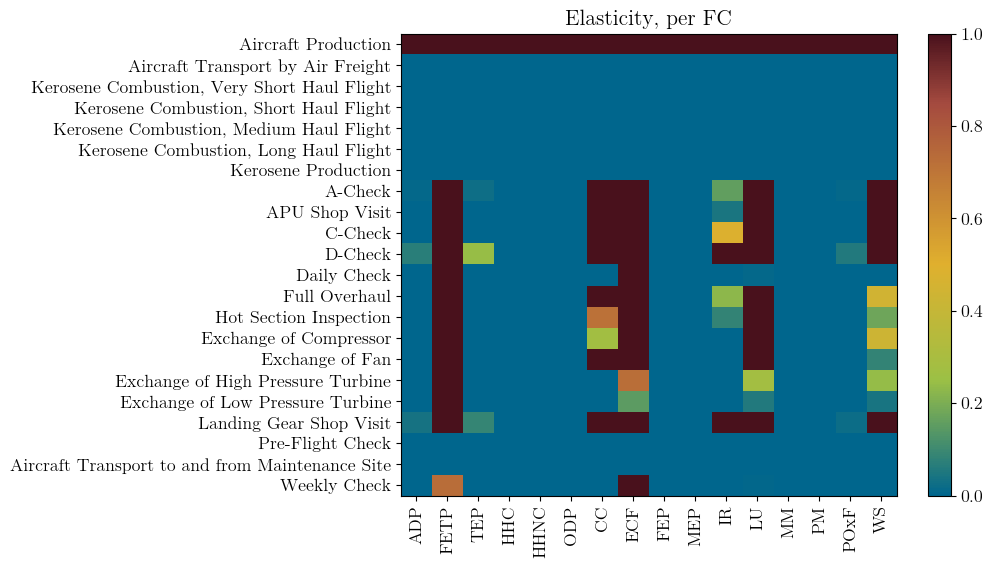

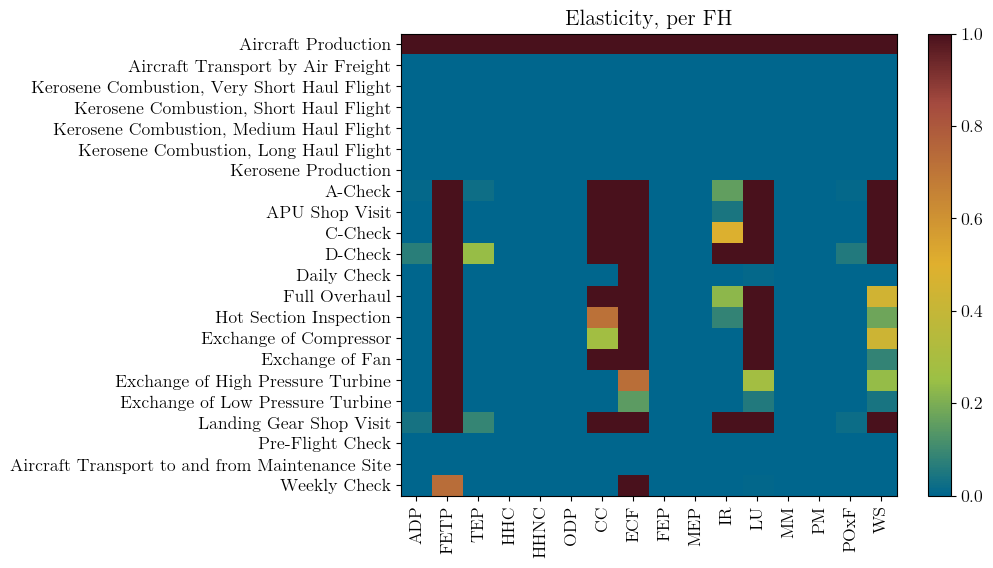

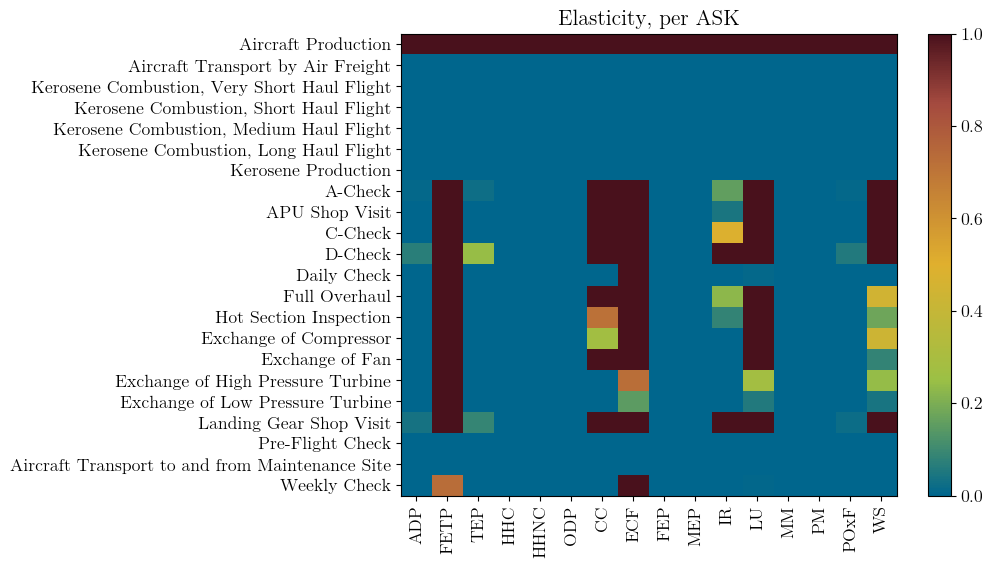

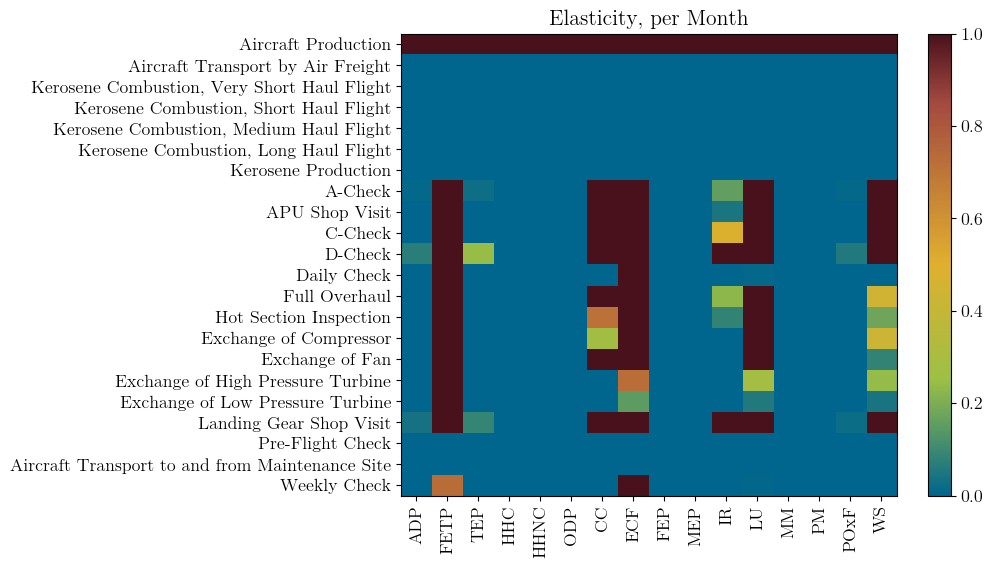

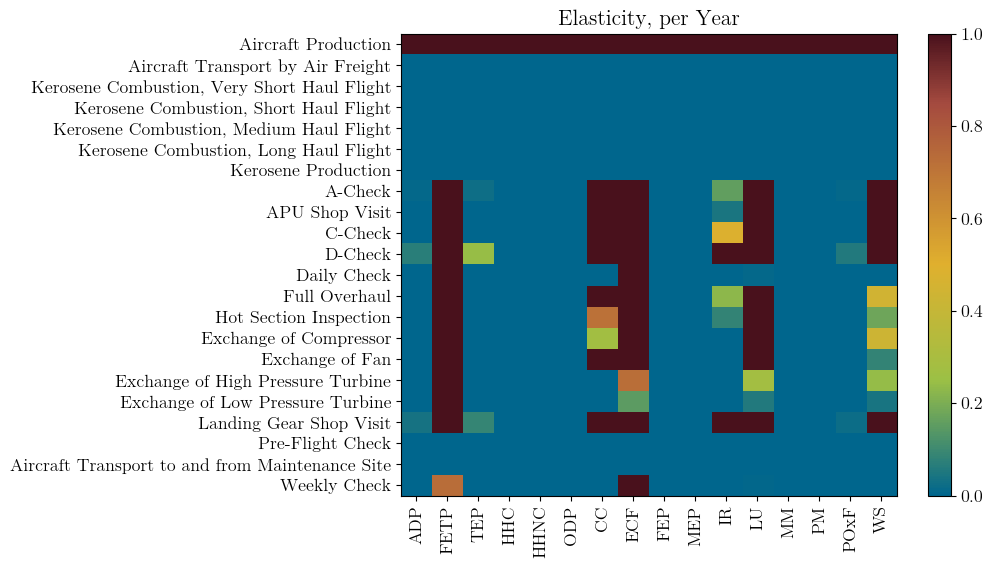

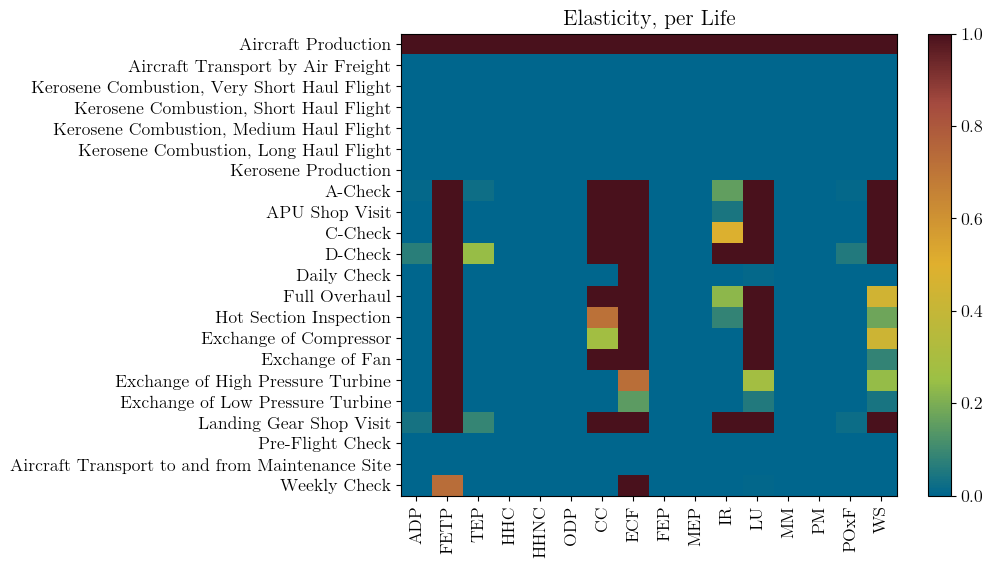

In [184]:
# custom define colours
blue = '#00668d'
light_blue = '#0099CE'
green = '#73a237'
light_green = '#9cc045'
gray = '#686867'
light_gray = '#b2b2b2'
yellow = '#e0b02e'
light_yellow = '#ffce44'
red = '#a44a3f'
purple = '#49111c'
pink = '#d88c9a'

colors = [blue, light_green, yellow, red, purple]
positions = [0, 0.25, 0.5, 0.85, 1]

from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", list(zip(positions, colors)))

for i, sensitivity_df in enumerate(sensitivity_dataframes):
    # Create a heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(sensitivity_df, cmap=custom_cmap, aspect='auto', vmin=0, vmax=1)
    plt.colorbar()
    plt.title(f'Sensitivity, per {fu_list[i]}')
    # set the index as the y labels
    plt.yticks(ticks=np.arange(len(sensitivity_df.index)), labels=sensitivity_df.index)
    # set the impact categories as the x labels
    plt.xticks(ticks=np.arange(len(sensitivity_df.columns)), labels=sensitivity_df.columns, rotation=90)
    plt.show()
    
for i, elasticity_df in enumerate(elasticity_dataframes):
    # Create a heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(elasticity_df, cmap=custom_cmap, aspect='auto', vmin=0, vmax=1)
    plt.colorbar()
    plt.title(f'Elasticity, per {fu_list[i]}')
    plt.yticks(ticks=np.arange(len(elasticity_df.index)), labels=elasticity_df.index)
    plt.xticks(ticks=np.arange(len(elasticity_df.columns)), labels=elasticity_df.columns, rotation=90)
    plt.show()
    
